# Principal Component Analysis

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

#### This notebook explores PCA concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [42]:
# General imports
import pandas as pd 
import numpy as np 
from numpy.linalg import norm
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)

# SciKit Learn
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")
# Same for csvs
sys.path.append(os.path.join(os.getcwd(), 'csvs'))
csvs_dir = "csvs"
csvs_files_paths = glob(f"{csvs_dir}/*.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [7]:
LIB = pd.read_csv("csvs/LIB/LIB.csv").set_index('year')
TFIDF = pd.read_csv("csvs/TFIDF/TFIDF_norm.csv").set_index("year")

### Running and Viewing PCA

In [ ]:
# Create PCA engine
# Use 3 components - cannot use more than the number of documents
pca_engine = PCA(n_components=3)

# Apply it to the TFIDF table to create a document count matrix
DCM = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)

# Set the column names
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]

# View
DCM

,PC0,PC1,PC2
year,,,
2013,-0.000449,0.000233,-6.423498e-17
2018,-0.000026,-0.000430,-6.423498e-17
2023,0.000474,0.000197,-6.423498e-17


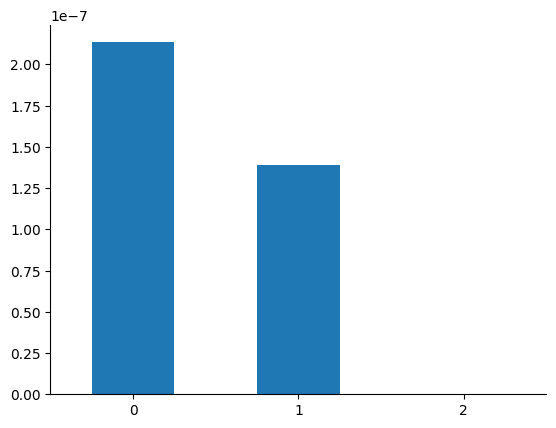

In [10]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0)
sns.despine()
plt.show()

Analysis:

The first and second components explain similar amounts of variance given the small scale of the y-axis, while the last component barely has any explanatory power.

In [ ]:
# Make a components table that essentially documents the explained variance of each term
# I.e., how much each term is part of any given component
# This will help in defining the components' meanings 
COMPS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
# Formatting and settings (columns, index, transpose for easy viewing)
COMPS.columns = ["PC{}".format(i) for i in COMPS.columns]
COMPS.index = TFIDF.columns
COMPS.index.name = 'term_str'
COMPS.T

term_str,0,00,000,0000007,000003,0000042,00001,0000152,00002,00003,...,ω,ωarag,ωcal,ϕ,ϕph2oph2o,ϕst,ϵ,ϵerror,ϵn,ϵy
PC0,6.019558e-07,7.906901e-08,-6.831860e-07,1.598800e-07,-9.502875e-08,-7.416355e-07,-2.846710e-06,-7.416355e-07,-7.416355e-07,8.764816e-07,...,-1.050306e-06,-6.404413e-07,-9.502875e-08,1.598800e-07,1.598800e-07,-1.591949e-07,-5.360707e-07,-7.416355e-07,-7.416355e-07,-9.502875e-08
PC1,-4.637642e-06,-6.184352e-07,6.593155e-07,1.278981e-07,-3.291240e-07,4.310978e-07,7.074932e-07,4.310978e-07,4.310978e-07,4.969761e-07,...,-5.749701e-07,-1.168499e-05,-3.291240e-07,1.278981e-07,1.278981e-07,-1.665108e-06,6.870126e-08,4.310978e-07,4.310978e-07,-3.291240e-07
PC2,-4.221712e-18,7.973634e-18,-3.638332e-19,-3.544740e-19,-7.056187e-19,-7.930082e-21,1.555689e-19,-7.930082e-21,-7.930082e-21,1.062273e-18,...,1.062242e-18,-2.477593e-19,-7.056187e-19,-3.544740e-19,-3.544740e-19,1.077075e-18,1.058864e-18,-7.930082e-21,-7.930082e-21,-7.056187e-19


### Visualizations

In [49]:
# A function to visualize the principal components
# Inputs: The DCM df, PCs a and b, 
def vis_pcs(DCM, a, b):#, label='year', hover_name='label'):
    return px.scatter(DCM, f"PC{a}", f"PC{b}") 
                    #color=LIB[label], 
                    #hover_name=LIB[hover_name], 
                    #marginal_x='box', height=800)

def vis_loadings(COMPS, a=0, b=1, hover_name='term_str'):
    return px.scatter(COMPS.reset_index(), f"PC{a}", f"PC{b}", 
                      text='term_str', 
                      marginal_x='box', 
                      height=800)

#### PC 0 and 1 

PC 2 has very little meaning, so do not visualize for the time being

In [50]:
fig = vis_pcs(DCM, 0, 1)
fig.show()